## Combining atlasopenmagic with ServiceX
This notebook showcases new features to handle ATLAS Open Data with `atlasopenmagic` using the `servicex` library under the hood. 
It starts with quick reminders on the current baseline workflows and follows it with demonstrations of the new features based on servicex.
###  1 - Baseline Workflow

In [1]:
import atlasopenmagic as atom
import uproot
import awkward as ak

In [2]:
# Using Z tt bar example dataset
sample_key=301333

In [3]:
atom.get_metadata(sample_key)

{'dataset_number': '301333',
 'physics_short': 'Pythia8EvtGen_A14NNPDF23LO_zprime3000_tt',
 'e_tag': 'e3723',
 'cross_section_pb': 0.0050843,
 'genFiltEff': 1.0,
 'kFactor': 1.0,
 'nEvents': 30000,
 'sumOfWeights': 30000.0,
 'sumOfWeightsSquared': 30000.0,
 'process': 'pp>Zprime>ttbar',
 'generator': 'Pythia8(v8.186)+EvtGen(v1.2.0)',
 'keywords': ['BSM', 'Zprime', 'resonance', 'ttbar'],
 'description': 'SSM Z prime (+str(m_zprime)+") to ttbar"',
 'job_path': 'https://gitlab.cern.ch/atlas-physics/pmg/infrastructure/mc15joboptions/-/tree/master/share/DSID301xxx/MC15.301333.Pythia8EvtGen_A14NNPDF23LO_zprime3000_tt.py',
 'CoMEnergy': None,
 'GenEvents': None,
 'GenTune': None,
 'PDF': None,
 'Release': None,
 'Filters': None,
 'cross_section_uncertainty': None,
 'hepmc_version': None,
 'release': {'name': '2024r-pp'}}

At this point on can get the URLs poiting to the sample's files throug XRootD (default). Different types of files can available:
- the orginal file containing all events (`skim="noskim"`)
- pre-skimed files containing a selection of the events (e.g `skim="exactly4lep"`)

In [4]:
url_to_file = atom.get_urls(sample_key, skim="noskim")
print(url_to_file)

['root://eospublic.cern.ch:1094//eos/opendata/atlas/rucio/mc20_13TeV/DAOD_PHYSLITE.38191516._000001.pool.root.1']


All following analysis code could use uproot to read the files from the URLs

In [5]:
uproot.open(url_to_file[0])  # open first file in the dataset

<ReadOnlyDirectory '/' at 0x00013f6b1fd0>

### 2 - New workflow with custom branch and event selection: 

- On-demand data delivery and transformation with `atom.get_data()`:

    - Grants fast and direct access to specific features of a sample. 
    - Done by specifying columns to load and optional event selection cuts instead of downloading the entire sample.  



Requires to setup for ServiceX by getting a token (ATLAS account currently) [instructions](https://servicex-frontend.readthedocs.io/en/stable/connect_servicex.html)

In [6]:
atom.get_data

<function atlasopenmagic.servicex_wrap.get_data(dataset: str | int, tree: str, branch_filter: str | list[str], selection: str | None = None, nfiles: int = -1, return_paths: bool = False, **kwargs)>

```python
def get_data(
    dataset: str | int,
    tree: str,
    branch_filter: str | list[str],
    selection: str | None = None,
    nfiles: int = -1,
    return_paths: bool = False,
    **kwargs,
):
    """Fetch data using ServiceX based on the given selection and dataset.

    Args:
        dataset (str): The dataset identifier. Can be DSID key, /eos path, XRootD url, or CernOpenData record ID
        tree (str): The name of the tree to query.
        branch_filter (str | list[str]): The branches to retrieve from the sample.
        selection (str) Optional: The selection criteria for the data.
        nfiles (int) Optional: Number of files to process.
        return_paths (bool) Optional: If True, returns downloaded paths to result files. 
                             If False returns loaded data in awkward arrays. Default is False.
        **kwargs: Additional keyword arguments for data delivery and conversion.

    Returns:
        filtered_files: Loaded in awkward arrays or a list of paths if specified
    """
```

#### 2.a - Investigate a feature with `get_data`
With get_data one can load only the revelant information for a specific study directly into an awkward array

In [8]:
#Tree to inspect in the Physlite file
tree="CollectionTree"
#Branch of interest
branch="AnalysisElectronsAuxDyn.pt"

In [9]:
result=atom.get_data(sample_key, tree = tree, branch_filter = branch)

Output()

Quickly investigate specific features of a sample with a simple interface and a short number of steps

In [12]:
print(f"Average electron pt over all events: {ak.mean(result[branch])/1_000:.2f} GeV for sample {sample_key}")

Average electron pt over all events: 112.28 GeV for sample 301333


#### 2.b - Request multiple columns at once
One can also quickly study different parameters at once by specifying them in the branch filter

E.g with relevant kinematic properties of an Analysis Electron object: 

In [13]:
branches = ["AnalysisElectronsAuxDyn.pt", "AnalysisElectronsAuxDyn.eta", "AnalysisElectronsAuxDyn.phi"]

In [15]:
result_many = atom.get_data(sample_key, tree = tree, branch_filter = branches)

Output()

Histogram a selection of events by using awkward masks directly onto `result_many`

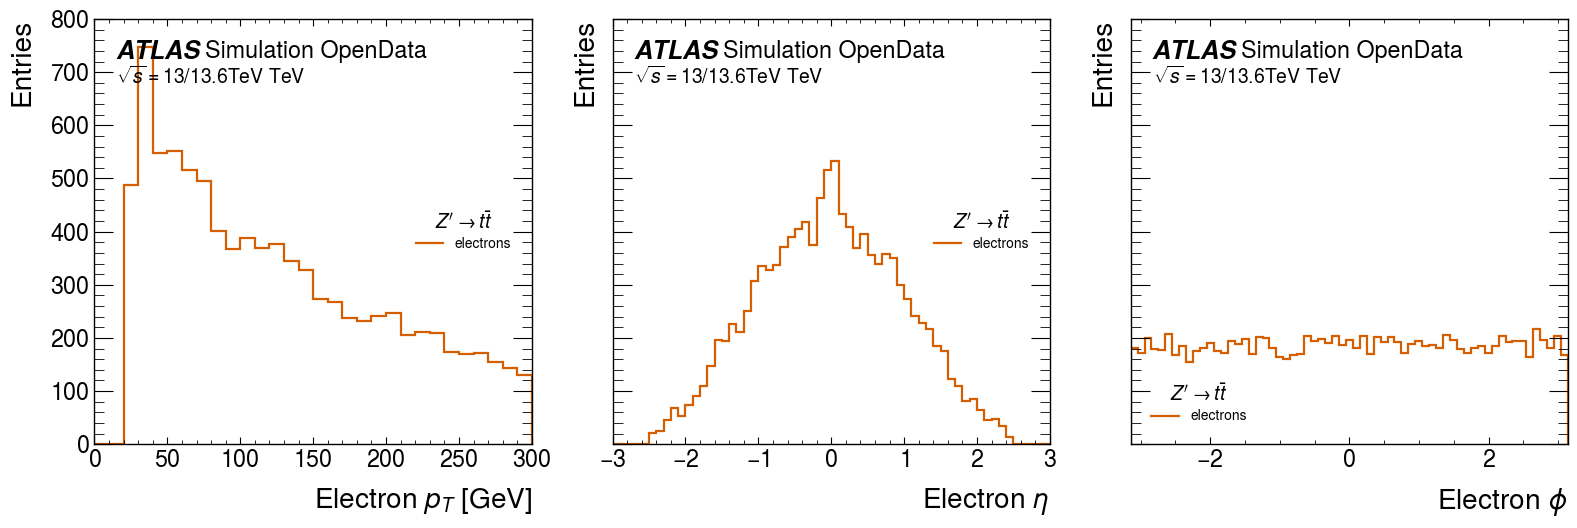

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep

normalize = False
mplhep.style.use("ATLAS")

PT_KEY  = branches[0]
ETA_KEY = branches[1]
PHI_KEY = branches[2]

pt_bins  = np.linspace(0, 300, 31)        # 10 GeV bins
eta_bins = np.linspace(-3.0, 3.0, 61)     # 0.1 bins
phi_bins = np.linspace(-np.pi, np.pi, 64) # ~0.1 bins

# Build a mask with awkward
mask = result_many[PT_KEY] > 25_000   # MeV 

label = r"$Z^\prime \to t\bar{t}$"

plots = [
    {
        "key": PT_KEY,
        "bins": pt_bins,
        "xlabel": r"Electron $p_T$ [GeV]",
        "transform": lambda x: x / 1000.0,  # MeV -> GeV
    },
    {
        "key": ETA_KEY,
        "bins": eta_bins,
        "xlabel": r"Electron $\eta$",
        "transform": lambda x: x,
    },
    {
        "key": PHI_KEY,
        "bins": phi_bins,
        "xlabel": r"Electron $\phi$",
        "transform": lambda x: x,
    },
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)

for ax, cfg in zip(axes, plots):
    key   = cfg["key"]
    bins  = cfg["bins"]
    xlabel = cfg["xlabel"]
    transform = cfg["transform"]

    # flatten awkward array, apply mask and transform
    x = ak.to_numpy(ak.ravel(result_many[key][mask]))
    x = transform(x)

    # histogram
    y, edges = np.histogram(x, bins=bins)
    if normalize and y.sum() > 0:
        y = y / y.sum()

    mplhep.histplot(y.astype(float), bins=edges, ax=ax,
                    histtype="step", label="electrons", linewidth=1.6)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Arbitrary units" if normalize else "Entries")
    ax.set_xlim(bins[0], bins[-1])
    ax.legend(title=label, ncol=1, fontsize=10)
    mplhep.atlas.label("OpenData", ax=ax, data=False, com="13/ 13.6 TeV")

plt.tight_layout()
plt.show()


#### 2.c- Filtering sample with custom events selection

Under the hood ServiceX's `UprootRawQuery` is being used. This query accepts expression cuts with awkward expressions such as `ak.sum`, `ak.any` that broadcast through the nested structures event-by-event. 

Complementary to the acessible predefined skims one can get with `get_urls`, this feature allows one to create any desired event selection on all sample files. 
The ServiceX server deploys multiple workers to apply the selection to each file in parallel, allowing fast access to the results.

In [19]:
selection = (
    "(sum(AnalysisJetsAuxDyn.pt > 25000, axis=1) > 3)"                          # at least 4 jets with Pt > 25 GeV
    " & (any(AnalysisElectronsAuxDyn.pt > 25000, axis=1))"                      # at least 1 electron with Pt > 25 GeV
)


In [22]:
selected_events =atom.get_data(sample_key, tree = tree, branch_filter = branches, selection = selection)

Output()

In [28]:
eff=len(selected_events)/len(result)*100
print(f"The selection cuts yield a {eff:2.1f} % efficiency for sample {sample_key}")

The selection cuts yield a 26.7 % efficiency for sample 301333


### 3 - Utility to peek into the sample structure
The `get_structure()` function can be used to take a quick peek at the fike structure of any sample.

It retrieves the name of available trees, the labels of branches within them and their base type.

It also gets metadata from the file's ATLAS metadata histogram such as ami tags.

In [29]:
atom.get_structure

<function atlasopenmagic.servicex_wrap.get_structure(dataset: str | int, **kwargs)>

One just needs to input the dataset key and an optional filter

In [30]:
physlite_structure = atom.get_structure(301333, filter_branch="AnalysisElectrons")
print(physlite_structure)

Output()


---------------------------
📁 Sample: Dataset
---------------------------

File Metadata ℹ️ :

── amiTag: e3723_s3681_r13167_r13146_p6026
── beamEnergy: 6500000.0
── beamType: collisions
── conditionsTag: OFLCOND-MC16-SDR-RUN2-09
── geometryVersion: ATLAS-R2-2016-01-00-01
── isDataOverlay: 0
── mcProcID: 301333.0
── simFlavour: FullG4
── mcCampaign: mc20a

---------------------------

File structure with branch filter 🌿 'AnalysisElectrons':


🌳 Tree: ##Params;3
   ├── Branches:

🌳 Tree: ##Params;2
   ├── Branches:

🌳 Tree: ##Shapes;3
   ├── Branches:

🌳 Tree: ##Shapes;2
   ├── Branches:

🌳 Tree: ##Links;3
   ├── Branches:

🌳 Tree: ##Links;2
   ├── Branches:

🌳 Tree: MetaData
   ├── Branches:

🌳 Tree: MetaDataHdr
   ├── Branches:

🌳 Tree: MetaDataHdrForm
   ├── Branches:

🌳 Tree: CollectionTree
   ├── Branches:
   │   ├── AnalysisElectronsAux. ; dtype: AsStridedObjects(Model_xAOD_3a3a_AuxContainerBase_v1)
   │   ├── AnalysisElectrons ; dtype: AsObjects(Unknown_DataVector_3c_xAOD_3a3a_E

Combined with `get_data` this functionality is very usefull to remotely identify the branches that are of interest. 

### Extra information:

Other input types 

This `atom` wrappers allow data access through all datasetfinder protocols ServiceX can handle. 

This includes:
- rucio - `scope:somesample or just somesample`
- xrootd - `root://`
- HTTPS - URLs, Signed URLs
- filelist - multiple links at once 
- eos path - `/eos/opendata/atlas/rucio/somefile.root`
- cernopendata portal ID - `80018` 